In [1]:
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.stats as st
from scipy.interpolate import interp1d

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/CONTACT/STIS/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

Poisson errors

In [4]:
# Poisson distribution
def poisson(n, lam):
    
    return lam**n*np.exp(-lam)/np.math.factorial(n)

# Equation for upper bound
def lam_u_eqn(lam_u, n, C):
    
    # Generate array of x values
    x_arr = np.arange(0,n+1)
    
    poisson_x = np.array([poisson(x, lam_u) for x in x_arr])
    
    return np.sum(poisson_x)-(1-C)

# Equation for lower bound
def lam_l_eqn(lam_l, n, C):
    
    # Generate array of x values
    x_arr = np.arange(0,n)
    
    poisson_x = np.array([poisson(x, lam_l) for x in x_arr])
    
    return np.sum(poisson_x)-C

# Approximate solutions for seeding
def lam_u_approx(n, C):
    
    # First compute number of Gaussian sigma
    S = st.norm.ppf(C)
    
    # Now use the formula
    return n + S*np.sqrt(n+1) + ((S**2+2)/3)

def lam_l_approx(n, C):
    
    if(n==0):
        return 0
    
    # First compute number of Gaussian sigma
    S = st.norm.ppf(C)
    
    # Now use the formula
    return n - S*np.sqrt(n) + ((S**2-1)/3)

# Solve upper bound
def lam_u_eqn_solve(n, C):
    
    lam_u = opt.fsolve(lam_u_eqn, x0=lam_u_approx(n, C), args=(n, C))[0]
        
    return lam_u

# Solve lower bound
def lam_l_eqn_solve(n, C):
    
    if(n==0):
        return 0
    
    lam_l = opt.fsolve(lam_l_eqn, x0=lam_l_approx(n, C), args=(n, C))[0]
    
    return lam_l

In [5]:
n_arr = np.arange(0, 100)
lam_u_exact_arr = np.array([lam_u_eqn_solve(n, 0.8413) for n in n_arr])
lam_l_exact_arr = np.array([lam_l_eqn_solve(n, 0.8413) for n in n_arr])
lam_l_interp = interp1d(n_arr, lam_l_exact_arr, fill_value='extrapolate')
lam_u_interp = interp1d(n_arr, lam_u_exact_arr, fill_value='extrapolate')

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5565/22264841.py:4: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return lam**n*np.exp(-lam)/np.math.factorial(n)


Function to co-add

In [6]:
def form_coadd(exp_names):
    
    # Get list of FITS files
    fits_list = [fits.open(rootdir+'J011035/unstitched_es=4/{}_x1d.fits'.format(e))[1] for e in exp_names]
    
    # Save grid shape
    n_exps = len(exp_names)
    n_orders = fits_list[0].data['wavelength'].shape[0]
    n_pixels = fits_list[0].data['wavelength'].shape[1]
    
    # Get exposure times
    exp_times = [f.header['exptime'] for f in fits_list]
    
    # From all exposures, all orders, all pixels, load in wavelengths, gross counts, background counts, exposure times, data quality flags, and flux
    spec_data = np.zeros((n_exps, n_orders, n_pixels, 6))

    for i in range(n_exps):
        for j in range(n_orders):
            # Load orders in reverse because that means increasing wavelengths
            spec_data[i,j,:,0] = fits_list[i].data[n_orders-j-1]['wavelength']
            spec_data[i,j,:,1] = fits_list[i].data[n_orders-j-1]['gross']*exp_times[i] # Convert to counts
            spec_data[i,j,:,2] = fits_list[i].data[n_orders-j-1]['background']*exp_times[i] # To give net counts
            spec_data[i,j,:,3] = exp_times[i] # For weighting multiple exposures
            spec_data[i,j,:,4] = fits_list[i].data[n_orders-j-1]['dq']
            spec_data[i,j,:,5] = fits_list[i].data[n_orders-j-1]['flux'] # For flux calibration later
            
    # Some orders have overlapping wavelengths, so take care of that by modifying the wavelength grid
    wav_order_grid = np.zeros((n_orders, n_pixels))
    # Lowest wavelength order is fine, keep as is
    wav_order_grid[0,:] = spec_data[0,0,:,0]

    # For each subsequent order
    for i in range(n_orders-1):

        # Wavelengths of order 1
        wav_order_1 = spec_data[0,i,:,0]
        # Wavelengths of order 2
        wav_order_2 = spec_data[0,i+1,:,0]

        # Compute differences of order 1 wavelengths from the 0th element of order 2
        del_wav_arr = wav_order_1-wav_order_2[0]

        # This operation gives the index of the element of order 1 whose wavelength is right before the 0th element of order 2
        idx = list(del_wav_arr).index(max(del_wav_arr[del_wav_arr<0]))

        # Number of pixels in first order that are offset from the second order
        n_rem_order_1 = len(wav_order_1[idx:])
        # Copy over wavelengths to the second order
        wav_order_2[0:n_rem_order_1] = wav_order_1[idx:].copy()

        # Save the modified second order in the wavelength grid
        wav_order_grid[i+1,:] = wav_order_2.copy()
        
    # Interpolate fluxes over the rectified wavelength grid
    spec_data_interp = spec_data.copy()

    for i in range(n_exps):
        for j in range(n_orders):

            # The shifted wavelength grid for an order
            wav_order = wav_order_grid[j,:]

            # Original grid
            wav_order_og = spec_data[i,j,:,0]
            gross_order_og = spec_data[i,j,:,1]
            bg_order_og = spec_data[i,j,:,2]
            flux_order_og = spec_data[i,j,:,5]

            # Interpolate flux and variance
            gross_order = np.interp(wav_order, wav_order_og, gross_order_og)
            bg_order = np.interp(wav_order, wav_order_og, bg_order_og)
            flux_order = np.interp(wav_order, wav_order_og, flux_order_og)

            # Store in the new full grid
            spec_data_interp[i,j,:,0] = wav_order
            spec_data_interp[i,j,:,1] = gross_order
            spec_data_interp[i,j,:,2] = bg_order
            spec_data_interp[i,j,:,5] = flux_order        

    # Stitch wavelengths
    wav_stitch = np.unique(wav_order_grid)     
    
    # Map fluxes and errors for each wavelength across all exposures
    wav_dict = {w:[] for w in wav_stitch}

    for i in range(n_exps):
        for j in range(n_orders):

            wav_order = spec_data_interp[i,j,:,0]

            for k in range(n_pixels):

                w = spec_data_interp[i,j,k,0] # Wavelength
                g = spec_data_interp[i,j,k,1] # Gross
                bg = spec_data_interp[i,j,k,2] # Background
                et = spec_data_interp[i,j,k,3] # Exposure time
                dq = spec_data_interp[i,j,k,4] # Data quality
                f = spec_data_interp[i,j,k,5] # Flux

                # Trim edges of each order
                if wav_order[0]+2<w<wav_order[-1]-5:            
                    wav_dict[w].append([g,bg,et,dq,f])    
                    
                    
    # Store co-added gross and net count rates
    gross_cts_stitch = np.zeros(len(wav_stitch))
    bg_cts_stitch = np.zeros(len(wav_stitch))
    err_cts_stitch = np.zeros(len(wav_stitch))
    exp_time_stitch = np.zeros(len(wav_stitch))

    # For flux calibration later
    net_ct_rate_dict = {}
    flux_dict = {}

    for i in range(len(wav_stitch)):

        # Get wavelength, and quantities (flux, error) to be combined
        w = wav_stitch[i]
        spec_arr = np.array(wav_dict[w])

        if len(spec_arr)!=0:
            gross_arr = spec_arr[:,0]
            bg_arr = spec_arr[:,1]
            et_arr = spec_arr[:,2]
            dq_arr = spec_arr[:,3]
            flux_arr = spec_arr[:,4]

            # Reject counts that have bad data quality
            idx = (dq_arr!=0)

            # Counts and exposure times after rejecting
            gross_arr = gross_arr[~idx]
            bg_arr = bg_arr[~idx]
            et_arr = et_arr[~idx]
            dq_arr = dq_arr[~idx]
            flux_arr = flux_arr[~idx]

            # Save net count rate and fluxes first
            net_ct_rate_dict[w] = (gross_arr-bg_arr)/et_arr
            flux_dict[w] = flux_arr

            # Record the co-added fluxes and errors
            gross_counts = np.sum(gross_arr)
            # Obtain errors using gross counts
            err_lo = gross_counts-lam_l_interp(gross_counts)
            err_hi = lam_u_interp(gross_counts)-gross_counts
            err = .5*(err_lo + err_hi) # Take the average    

            gross_cts_stitch[i] = gross_counts
            bg_cts_stitch[i] = np.sum(bg_arr)
            err_cts_stitch[i] = err
            exp_time_stitch[i] = np.sum(et_arr)
       
    # Convert counts to count rates to flux calibrate
    net_ct_rates_stitch = (gross_cts_stitch-bg_cts_stitch)/exp_time_stitch
    err_ct_rates_stitch = err_cts_stitch/exp_time_stitch
    
    # Create sensitivity function
    # Flatten wavelength array to account for scatter in relation
    wav_flat = []
    sens_flat = []
    for w in wav_stitch:

        if w in list(flux_dict.keys()):
            for i in range(len(flux_dict[w])):
                wav_flat.append(w)
                sens_flat.append(flux_dict[w][i]/net_ct_rate_dict[w][i])
        else:
            wav_flat.append(w)
            sens_flat.append(np.nan)
            
    # Median relation
    sens_med = np.zeros(len(wav_stitch))

    for i in range(len(wav_stitch)):
        w = wav_stitch[i]
        if w in list(flux_dict.keys()):
            sens_med[i] = np.median(flux_dict[w]/net_ct_rate_dict[w])
        else:
            sens_med[i] = 0
     
    # Flux calibrated
    flux_stitch = net_ct_rates_stitch*sens_med
    err_stitch = err_ct_rates_stitch*sens_med
    
    return wav_stitch, flux_stitch, err_stitch

Latest visit only

In [7]:
wav_stitch_latest, flux_stitch_latest, err_stitch_latest = form_coadd(['of8g06010', 'of8g06020', 'of8g06030'])

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5565/395989112.py:155: RuntimeWarning: invalid value encountered in divide
  net_ct_rates_stitch = (gross_cts_stitch-bg_cts_stitch)/exp_time_stitch
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5565/395989112.py:156: RuntimeWarning: divide by zero encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5565/395989112.py:156: RuntimeWarning: invalid value encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


All visits

In [8]:
wav_stitch_all, flux_stitch_all, err_stitch_all = form_coadd(['of8g05010', 'of8g05020', 'of8g05030', 'of8g06010', 'of8g06020', 'of8g06030', 'of8g08010', 'of8g08020'])

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5565/395989112.py:155: RuntimeWarning: invalid value encountered in divide
  net_ct_rates_stitch = (gross_cts_stitch-bg_cts_stitch)/exp_time_stitch
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5565/395989112.py:156: RuntimeWarning: divide by zero encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5565/395989112.py:156: RuntimeWarning: invalid value encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch


Compare

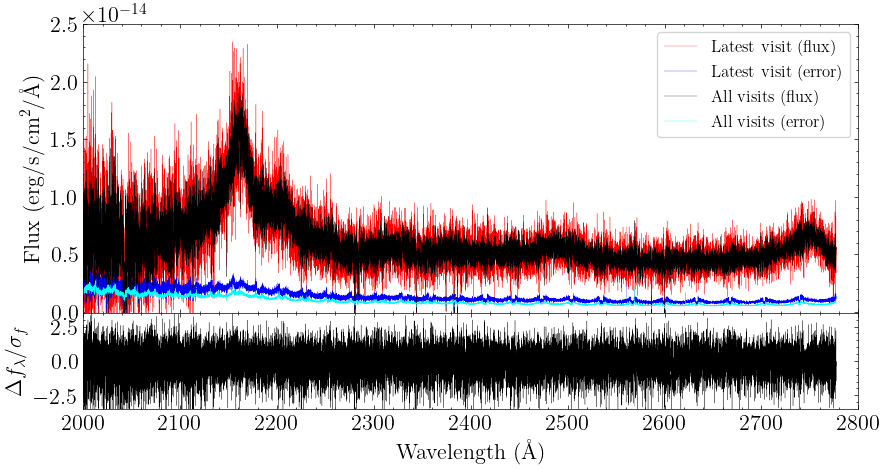

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(wav_stitch_latest, flux_stitch_latest, where='mid', color='red', alpha=1, lw=.2, label="Latest visit (flux)")
axes[0].step(wav_stitch_latest, err_stitch_latest, where='mid', color='blue', alpha=1, lw=.2, label="Latest visit (error)")

axes[0].step(wav_stitch_all, flux_stitch_all, where='mid', color='black', alpha=1, lw=.2, label="All visits (flux)")
axes[0].step(wav_stitch_all, err_stitch_all, where='mid', color='cyan', alpha=1, lw=.2, label="All visits (error)")

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

axes[0].legend(loc='upper right')
axes[0].set_xlim(2000,2800)
axes[0].set_ylim(-1e-16,2.5e-14)
axes[0].legend()

axes[1].step(wav_stitch_all, (flux_stitch_latest-flux_stitch_all)/np.sqrt(err_stitch_latest**2+err_stitch_all**2), 
             alpha=1,lw=.2, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-3.5, 3.5)
plt.subplots_adjust(wspace=0.2, hspace=0)